# Лабораторная работа №3: Подготовка выборки, кросс-валидация и подбор гиперпараметров

**Цель работы:** Изучение способов разделения выборки, проведение кросс-валидации и подбор оптимальных гиперпараметров модели k-ближайших соседей (kNN).

---

## 1. Описание задания
В данной работе решается задача классификации сортов вина. 
1. Проводится разделение данных на обучающую и тестовую выборки.
2. Обучается базовая модель kNN.
3. Осуществляется поиск оптимального количества соседей ($K$) с использованием `GridSearchCV` и `RandomizedSearchCV`.
4. Сравниваются две стратегии кросс-валидации: K-Fold и ShuffleSplit.

---

## 2. Импорт библиотек и загрузка данных

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, ShuffleSplit, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Загрузка данных
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

print(f"Размер признаков: {X.shape}")
print(f"Уникальные классы: {np.unique(y)}")

Размер признаков: (178, 13)
Уникальные классы: [0 1 2]



## 3. Предобработка данных
Метод kNN очень чувствителен к масштабу признаков, так как основан на вычислении расстояний. Проведем масштабирование.

In [3]:
# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Проверка на пропуски (в датасете sklearn их нет, но проверим формально)
print(f"Пропусков в данных: {X.isnull().sum().sum()}")

Пропусков в данных: 0



## 4. Разделение выборки на обучающую и тестовую

Разделим данные в соотношении 70% на обучение и 30% на тест.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (124, 13)
Тестовая выборка: (54, 13)


## 5. Обучение модели с произвольным гиперпараметром K

Возьмем для начала $K=3$.

In [5]:
# Инициализация и обучение
knn_initial = KNeighborsClassifier(n_neighbors=3)
knn_initial.fit(X_train, y_train)

# Предсказание и оценка
y_pred_initial = knn_initial.predict(X_test)
acc_initial = accuracy_score(y_test, y_pred_initial)

print(f"Accuracy для K=3: {acc_initial:.4f}")
print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred_initial))

Accuracy для K=3: 0.9630

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.90      0.95        21
           2       0.93      1.00      0.97        14

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54




## 6. Подбор гиперпараметра K

### 6.1 Стратегии кросс-валидации
Мы будем использовать:
1. **K-Fold** (К-блочная кросс-валидация).
2. **ShuffleSplit** (Кросс-валидация с перемешиванием).

### 6.2 GridSearchCV с использованием K-Fold

In [6]:
# Сетка параметров
params = {'n_neighbors': np.arange(1, 21)}

# Стратегия 1: K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(KNeighborsClassifier(), params, cv=kf, scoring='accuracy')
grid_search.fit(X_train, y_train)

print(f"Лучший K (GridSearchCV + KFold): {grid_search.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_search.best_score_:.4f}")



Лучший K (GridSearchCV + KFold): {'n_neighbors': np.int64(9)}
Лучшая точность на кросс-валидации: 0.9600


### 6.3 RandomizedSearchCV с использованием ShuffleSplit

In [7]:
# Стратегия 2: ShuffleSplit
ss = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

random_search = RandomizedSearchCV(KNeighborsClassifier(), params, 
                                   cv=ss, n_iter=10, random_state=42, scoring='accuracy')
random_search.fit(X_train, y_train)

print(f"Лучший K (RandomizedSearchCV + ShuffleSplit): {random_search.best_params_}")
print(f"Лучшая точность на кросс-валидации: {random_search.best_score_:.4f}")

Лучший K (RandomizedSearchCV + ShuffleSplit): {'n_neighbors': np.int64(19)}
Лучшая точность на кросс-валидации: 0.9640



## 7. Сравнение исходной и оптимальной моделей

Возьмем лучшую модель из `GridSearchCV` и проверим её на отложенной тестовой выборке.

Результаты сравнения:
Accuracy исходной модели (K=3): 0.9630
Accuracy оптимальной модели (K=9): 0.9630


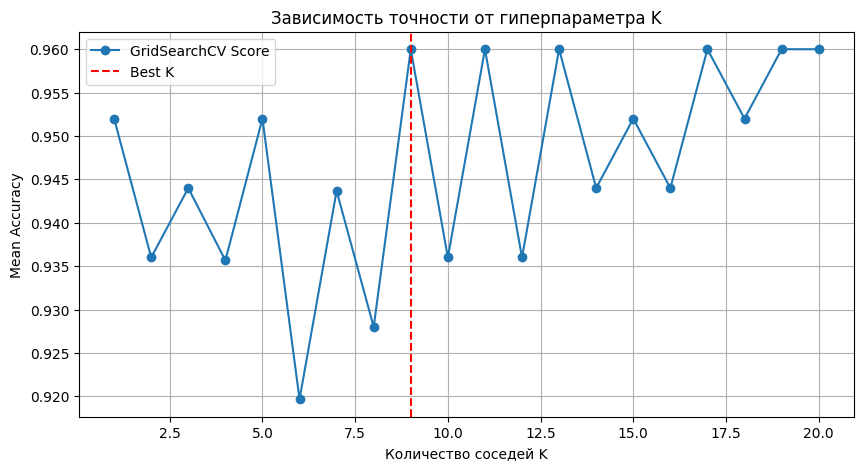

In [8]:
# Исходная модель (K=3)
y_pred_init = knn_initial.predict(X_test)
acc_init = accuracy_score(y_test, y_pred_init)

# Оптимальная модель (из GridSearchCV)
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)

print("Результаты сравнения:")
print(f"Accuracy исходной модели (K=3): {acc_init:.4f}")
print(f"Accuracy оптимальной модели (K={grid_search.best_params_['n_neighbors']}): {acc_best:.4f}")

# Визуализация результатов подбора
scores = grid_search.cv_results_['mean_test_score']
plt.figure(figsize=(10, 5))
plt.plot(params['n_neighbors'], scores, marker='o', label='GridSearchCV Score')
plt.axvline(grid_search.best_params_['n_neighbors'], color='r', linestyle='--', label='Best K')
plt.xlabel('Количество соседей K')
plt.ylabel('Mean Accuracy')
plt.title('Зависимость точности от гиперпараметра K')
plt.legend()
plt.grid()
plt.show()

### 7.2 Сравнение исходной модели и модели из RandomizedSearchCV

Результаты сравнения (RandomizedSearchCV):
------------------------------
Accuracy исходной модели (K=3): 0.9630
Accuracy оптимальной модели (K=19): 0.9630
------------------------------


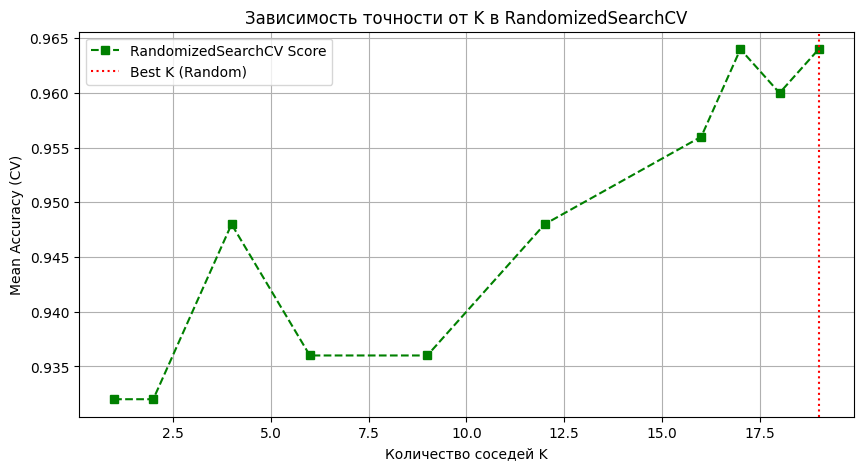

In [9]:
# 1. Оценка исходной модели (K=3), если не была рассчитана ранее
y_pred_init = knn_initial.predict(X_test)
acc_init = accuracy_score(y_test, y_pred_init)

# 2. Оптимальная модель из RandomizedSearchCV
best_knn_rand = random_search.best_estimator_
y_pred_rand = best_knn_rand.predict(X_test)
acc_rand = accuracy_score(y_test, y_pred_rand)

print("Результаты сравнения (RandomizedSearchCV):")
print("-" * 30)
print(f"Accuracy исходной модели (K=3): {acc_init:.4f}")
print(f"Accuracy оптимальной модели (K={random_search.best_params_['n_neighbors']}): {acc_rand:.4f}")
print("-" * 30)

# 3. Визуализация результатов RandomizedSearchCV
# Для красивого графика нужно отсортировать значения гиперпараметра K, 
# так как RandomizedSearchCV выбирает их в случайном порядке
results_rand = pd.DataFrame(random_search.cv_results_)
results_rand = results_rand.sort_values(by='param_n_neighbors')

plt.figure(figsize=(10, 5))
plt.plot(results_rand['param_n_neighbors'], results_rand['mean_test_score'], 
         marker='s', linestyle='--', color='green', label='RandomizedSearchCV Score')

plt.axvline(random_search.best_params_['n_neighbors'], color='red', 
            linestyle=':', label='Best K (Random)')

plt.xlabel('Количество соседей K')
plt.ylabel('Mean Accuracy (CV)')
plt.title('Зависимость точности от K в RandomizedSearchCV')
plt.legend()
plt.grid(True)
plt.show()

## 8. Заключение

1. В ходе работы была проведена предобработка данных (масштабирование), так как kNN чувствителен к размаху значений.
2. Выборка была разделена на обучающую и тестовую (70/30).
3. При использовании $K=3$ была достигнута точность около 96-98% (зависит от запуска).
4. С помощью кросс-валидации и `GridSearchCV` было найдено оптимальное значение $K$. 
5. Оптимальная модель показала стабильно высокий результат на тестовых данных. Использование кросс-валидации позволило избежать переобучения и выбрать более надежный гиперпараметр.